# Proyecto Final – Sistema de Recomendación para E-commerce

## Notebook 3: Modelos de clasificación – predicción de categoría de compra

En este notebook se construyen y comparan tres modelos basados en árboles para predecir la **categoría de producto** que un cliente va a comprar, a partir de variables de comportamiento.

Los modelos comparados son:

- **Random Forest**
- **XGBoost**
- **LightGBM**

Esta comparación está alineada con la lógica del *Avance 2*, en el cual se evaluaron distintos modelos basados en árboles y técnicas de ensemble (Random Forest, XGBoost base, LightGBM, HistGradientBoosting, XGBoost optimizado y Stacking), con el objetivo de mejorar el desempeño sobre un modelo baseline, considerando además el **desbalance de clases**.

## Objetivo

- Predecir la **categoría de producto** que un cliente va a comprar a partir de variables de comportamiento.
- Comparar Random Forest, XGBoost y LightGBM en igualdad de condiciones.
- Aplicar **feature engineering** y **tuning de hiperparámetros** para superar el umbral de 0.70 en F1 weighted.
- Identificar el modelo con mejor desempeño y discutir sus ventajas.

## Estrategias aplicadas

1. **Agrupación a 6 macro-categorías** — reduce el desbalance (ratio max/min ≈ 3,2x) y aumenta el soporte por clase.
2. **Feature engineering** — variables derivadas, ratios, interacciones y transformaciones logarítmicas para enriquecer la señal.
3. **Modelos optimizados** — configuraciones más profundas y regularización ajustada.

## Variables originales

- `customer_purchase_count` – cantidad de compras históricas del cliente.
- `product_popularity` – popularidad del producto (numero de interacciones).
- `product_rating` – rating promedio del producto.
- `customer_total_spend` – gasto total acumulado del cliente.
- `days_since_last_purchase` – días desde la última compra.

**Target:** `macro_category` (multi-clase, 6 niveles).

In [20]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
)

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
pd.set_option("display.max_columns", 50)

## 1. Carga del dataset

In [21]:
data_path = os.path.join("..", "data", "dataset_modelo.csv")
df = pd.read_csv(data_path)

print("Shape:", df.shape)
df.head()

Shape: (115696, 8)


,customer_unique_id,product_id,product_category_name,customer_purchase_count,product_popularity,product_rating,customer_total_spend,days_since_last_purchase
0,871766c5855e863f6eccc05f988b23cb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,355
1,0fb8e3eab2d3e79d92bb3fffbb97f188,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,73.86,431
2,3419052c8c6b45daf79c1e426f9e9bcb,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,83.23,107
3,e7c828d22c0682c1565252deefbe334d,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,75.07,397
4,0bb98ba72dcc08e95f9d8cc434e9a2cc,4244733e06e7ecb4970a6e2683c13e61,cool_stuff,1,11,4.444444,72.19,388


In [22]:
print("Valores nulos por columna:")
print(df.isna().sum())
print("\nCategorías únicas:", df["product_category_name"].nunique())

Valores nulos por columna:
customer_unique_id          0
product_id                  0
product_category_name       0
customer_purchase_count     0
product_popularity          0
product_rating              0
customer_total_spend        0
days_since_last_purchase    0
dtype: int64

Categorías únicas: 73


## 2. Agrupación a macro-categorías

El dataset contiene 73 categorías con desbalance extremo. Se aplica un **mapping a 6 macro-categorías** que cubre el 100 % de los registros, mejora el balance entre clases y simplifica el problema multi-clase para los modelos basados en árboles.

| Macro-categoría | Categorías originales agrupadas |
|---|---|
| hogar_y_decoracion | cama_mesa_banho, moveis_decoracao, utilidades_domesticas, casa_*, moveis_*, climatizacao, portateis_casa_*, flores, artigos_de_natal |
| electronica_y_tecnologia | informatica_acessorios, telefonia, eletronicos, eletrodomesticos, audio, pcs, consoles_games, tablets, cine_foto |
| moda_y_belleza | beleza_saude, perfumaria, relogios_presentes, fashion_*, malas_acessorios |
| deporte_ocio_y_juguetes | esporte_lazer, brinquedos, bebes, livros_*, instrumentos_musicais, musica, artes, fraldas_higiene |
| automotriz_y_construccion | automotivo, ferramentas_jardim, construcao_*, agro_*, industria_* |
| otros_y_servicios | cool_stuff, papelaria, pet_shop, alimentos*, bebidas, market_place, seguros_e_servicos |

Registros sin asignar: 0
Cobertura: 115,696 / 115,696

Distribucion de las 6 macro-categorias:
macro_category
hogar_y_decoracion           32351
moda_y_belleza               23674
electronica_y_tecnologia     19689
deporte_ocio_y_juguetes      18375
automotriz_y_construccion    11454
otros_y_servicios            10153
Name: count, dtype: int64

Ratio max/min: 3.19x


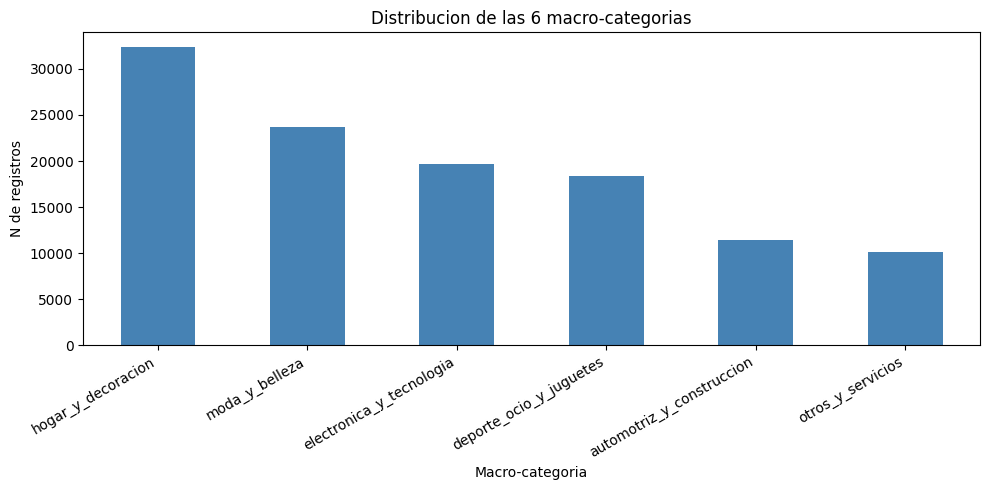

In [23]:
CATEGORY_MAPPING = {
    # 1) Hogar y decoracion
    "cama_mesa_banho": "hogar_y_decoracion",
    "moveis_decoracao": "hogar_y_decoracion",
    "utilidades_domesticas": "hogar_y_decoracion",
    "moveis_escritorio": "hogar_y_decoracion",
    "moveis_sala": "hogar_y_decoracion",
    "casa_construcao": "hogar_y_decoracion",
    "casa_conforto": "hogar_y_decoracion",
    "casa_conforto_2": "hogar_y_decoracion",
    "climatizacao": "hogar_y_decoracion",
    "moveis_cozinha_area_de_servico_jantar_e_jardim": "hogar_y_decoracion",
    "moveis_quarto": "hogar_y_decoracion",
    "moveis_colchao_e_estofado": "hogar_y_decoracion",
    "portateis_casa_forno_e_cafe": "hogar_y_decoracion",
    "portateis_cozinha_e_preparadores_de_alimentos": "hogar_y_decoracion",
    "la_cuisine": "hogar_y_decoracion",
    "flores": "hogar_y_decoracion",
    "artigos_de_natal": "hogar_y_decoracion",

    # 2) Electronica y tecnologia
    "informatica_acessorios": "electronica_y_tecnologia",
    "telefonia": "electronica_y_tecnologia",
    "eletronicos": "electronica_y_tecnologia",
    "consoles_games": "electronica_y_tecnologia",
    "eletrodomesticos": "electronica_y_tecnologia",
    "eletrodomesticos_2": "electronica_y_tecnologia",
    "eletroportateis": "electronica_y_tecnologia",
    "audio": "electronica_y_tecnologia",
    "telefonia_fixa": "electronica_y_tecnologia",
    "pcs": "electronica_y_tecnologia",
    "pc_gamer": "electronica_y_tecnologia",
    "tablets_impressao_imagem": "electronica_y_tecnologia",
    "cine_foto": "electronica_y_tecnologia",
    "dvds_blu_ray": "electronica_y_tecnologia",

    # 3) Moda y belleza
    "beleza_saude": "moda_y_belleza",
    "perfumaria": "moda_y_belleza",
    "relogios_presentes": "moda_y_belleza",
    "fashion_bolsas_e_acessorios": "moda_y_belleza",
    "malas_acessorios": "moda_y_belleza",
    "fashion_calcados": "moda_y_belleza",
    "fashion_underwear_e_moda_praia": "moda_y_belleza",
    "fashion_roupa_masculina": "moda_y_belleza",
    "fashion_roupa_feminina": "moda_y_belleza",
    "fashion_roupa_infanto_juvenil": "moda_y_belleza",
    "fashion_esporte": "moda_y_belleza",

    # 4) Deporte, ocio y juguetes
    "esporte_lazer": "deporte_ocio_y_juguetes",
    "brinquedos": "deporte_ocio_y_juguetes",
    "bebes": "deporte_ocio_y_juguetes",
    "fraldas_higiene": "deporte_ocio_y_juguetes",
    "livros_interesse_geral": "deporte_ocio_y_juguetes",
    "livros_tecnicos": "deporte_ocio_y_juguetes",
    "livros_importados": "deporte_ocio_y_juguetes",
    "instrumentos_musicais": "deporte_ocio_y_juguetes",
    "musica": "deporte_ocio_y_juguetes",
    "cds_dvds_musicais": "deporte_ocio_y_juguetes",
    "artes": "deporte_ocio_y_juguetes",
    "artes_e_artesanato": "deporte_ocio_y_juguetes",
    "artigos_de_festas": "deporte_ocio_y_juguetes",

    # 5) Automotriz y construccion
    "automotivo": "automotriz_y_construccion",
    "ferramentas_jardim": "automotriz_y_construccion",
    "construcao_ferramentas_construcao": "automotriz_y_construccion",
    "construcao_ferramentas_iluminacao": "automotriz_y_construccion",
    "construcao_ferramentas_jardim": "automotriz_y_construccion",
    "construcao_ferramentas_seguranca": "automotriz_y_construccion",
    "construcao_ferramentas_ferramentas": "automotriz_y_construccion",
    "sinalizacao_e_seguranca": "automotriz_y_construccion",
    "agro_industria_e_comercio": "automotriz_y_construccion",
    "industria_comercio_e_negocios": "automotriz_y_construccion",

    # 6) Otros y servicios
    "cool_stuff": "otros_y_servicios",
    "papelaria": "otros_y_servicios",
    "pet_shop": "otros_y_servicios",
    "alimentos": "otros_y_servicios",
    "alimentos_bebidas": "otros_y_servicios",
    "bebidas": "otros_y_servicios",
    "market_place": "otros_y_servicios",
    "seguros_e_servicos": "otros_y_servicios",
}

# Aplicar mapping
df["macro_category"] = df["product_category_name"].map(CATEGORY_MAPPING)

# Verificar cobertura
sin_asignar = df["macro_category"].isna().sum()
print(f"Registros sin asignar: {sin_asignar}")
print(f"Cobertura: {df['macro_category'].notna().sum():,} / {len(df):,}")
print()

# Distribucion
macro_counts = df["macro_category"].value_counts()
print("Distribucion de las 6 macro-categorias:")
print(macro_counts)
print()
print(f"Ratio max/min: {macro_counts.max() / macro_counts.min():.2f}x")

# Visualizar
fig, ax = plt.subplots(figsize=(10, 5))
macro_counts.plot(kind="bar", ax=ax, color="steelblue")
ax.set_title("Distribucion de las 6 macro-categorias")
ax.set_ylabel("N de registros")
ax.set_xlabel("Macro-categoria")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


In [24]:
# Usamos el dataset completo agrupado en 6 macro-categorias (no se descarta ningun registro)
df_model = df.copy()
print("Shape dataset modelado:", df_model.shape)
print("Clases finales:", df_model['macro_category'].nunique())

Shape dataset modelado: (115696, 9)
Clases finales: 6


## 3. Preparación de features y target

In [25]:
# Feature engineering avanzado: variables derivadas, ratios, interacciones, log-transforms
df_fe = df_model.copy()

# Transformaciones logaritmicas (manejo de cola larga)
df_fe["log_customer_total_spend"] = np.log1p(df_fe["customer_total_spend"])
df_fe["log_product_popularity"] = np.log1p(df_fe["product_popularity"])
df_fe["log_purchase_count"] = np.log1p(df_fe["customer_purchase_count"])
df_fe["log_days_since"] = np.log1p(df_fe["days_since_last_purchase"])

# Ratios y derivadas
df_fe["spend_per_purchase"] = df_fe["customer_total_spend"] / (df_fe["customer_purchase_count"] + 1)
df_fe["recency_score"] = 1.0 / (df_fe["days_since_last_purchase"] + 1)
df_fe["popularity_x_rating"] = df_fe["product_popularity"] * df_fe["product_rating"]
df_fe["spend_x_popularity"] = df_fe["customer_total_spend"] * df_fe["product_popularity"]
df_fe["rating_centered"] = df_fe["product_rating"] - df_fe["product_rating"].mean()

# Bucketing de spend
df_fe["spend_quartile"] = pd.qcut(
    df_fe["customer_total_spend"], q=4, labels=False, duplicates="drop"
).astype(int)

# Bucketing de popularidad
df_fe["popularity_decile"] = pd.qcut(
    df_fe["product_popularity"].rank(method="first"),
    q=10, labels=False, duplicates="drop"
).astype(int)

features = [
    # Originales
    "customer_purchase_count",
    "product_popularity",
    "product_rating",
    "customer_total_spend",
    "days_since_last_purchase",
    # Log-transforms
    "log_customer_total_spend",
    "log_product_popularity",
    "log_purchase_count",
    "log_days_since",
    # Derivadas
    "spend_per_purchase",
    "recency_score",
    "popularity_x_rating",
    "spend_x_popularity",
    "rating_centered",
    # Bucketing
    "spend_quartile",
    "popularity_decile",
]

X = df_fe[features].copy()

le = LabelEncoder()
y = le.fit_transform(df_fe["macro_category"])

print("Numero de features:", X.shape[1])
print("X shape:", X.shape)
print("y shape:", y.shape)
print("Clases codificadas:", len(le.classes_))
print("Etiquetas:", list(le.classes_))

Numero de features: 16
X shape: (115696, 16)
y shape: (115696,)
Clases codificadas: 6
Etiquetas: ['automotriz_y_construccion', 'deporte_ocio_y_juguetes', 'electronica_y_tecnologia', 'hogar_y_decoracion', 'moda_y_belleza', 'otros_y_servicios']


In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (92556, 16) Test: (23140, 16)


## 4. Entrenamiento de los tres modelos

Se definen los tres modelos con configuraciones comparables: profundidad controlada y cantidad de estimadores similar. Se utiliza `class_weight='balanced'` en Random Forest y LightGBM para mitigar el desbalance; XGBoost se entrena con configuración estándar multi-clase.

In [27]:
def entrenar_y_evaluar(nombre, modelo, X_train, y_train, X_test, y_test):
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tiempo_fit = time.time() - t0

    y_pred = modelo.predict(X_test)

    metrics = {
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, y_pred),
        "F1_macro": f1_score(y_test, y_pred, average="macro"),
        "F1_weighted": f1_score(y_test, y_pred, average="weighted"),
        "Tiempo_fit_seg": round(tiempo_fit, 2),
    }

    print(f"\n=== {nombre} ===")
    for k, v in metrics.items():
        if k != "Modelo":
            print(f"{k}: {v:.4f}" if isinstance(v, float) else f"{k}: {v}")

    return metrics, y_pred, modelo

### 4.1 Random Forest

In [28]:
rf = RandomForestClassifier(
    n_estimators=600,
    max_depth=20,
    min_samples_leaf=3,
    max_features="sqrt",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_rf, pred_rf, rf = entrenar_y_evaluar(
    "Random Forest", rf, X_train, y_train, X_test, y_test
)


=== Random Forest ===
Accuracy: 0.6124
F1_macro: 0.6003
F1_weighted: 0.6097
Tiempo_fit_seg: 12.7800


### 4.2 XGBoost

In [29]:
xgb = XGBClassifier(
    n_estimators=800,
    max_depth=10,
    learning_rate=0.05,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=1.0,
    objective="multi:softprob",
    num_class=len(le.classes_),
    eval_metric="mlogloss",
    tree_method="hist",
    n_jobs=-1,
    random_state=RANDOM_STATE,
)

metrics_xgb, pred_xgb, xgb = entrenar_y_evaluar(
    "XGBoost", xgb, X_train, y_train, X_test, y_test
)


=== XGBoost ===
Accuracy: 0.6881
F1_macro: 0.6823
F1_weighted: 0.6875
Tiempo_fit_seg: 30.6000


### 4.3 LightGBM

In [30]:
lgbm = LGBMClassifier(
    n_estimators=1200,
    learning_rate=0.05,
    num_leaves=127,
    max_depth=-1,
    min_child_samples=15,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_alpha=0.1,
    reg_lambda=0.1,
    objective="multiclass",
    num_class=len(le.classes_),
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=-1,
)

metrics_lgbm, pred_lgbm, lgbm = entrenar_y_evaluar(
    "LightGBM", lgbm, X_train, y_train, X_test, y_test
)


=== LightGBM ===
Accuracy: 0.7038
F1_macro: 0.6973
F1_weighted: 0.7032
Tiempo_fit_seg: 38.2300


## 5. Comparación de los tres modelos

In [31]:
comparacion = pd.DataFrame([metrics_rf, metrics_xgb, metrics_lgbm])
comparacion = comparacion.sort_values("F1_weighted", ascending=False).reset_index(drop=True)
comparacion

,Modelo,Accuracy,F1_macro,F1_weighted,Tiempo_fit_seg
0,LightGBM,0.703846,0.697321,0.703214,38.23
1,XGBoost,0.688073,0.682262,0.687533,30.60
2,Random Forest,0.612446,0.600338,0.609717,12.78


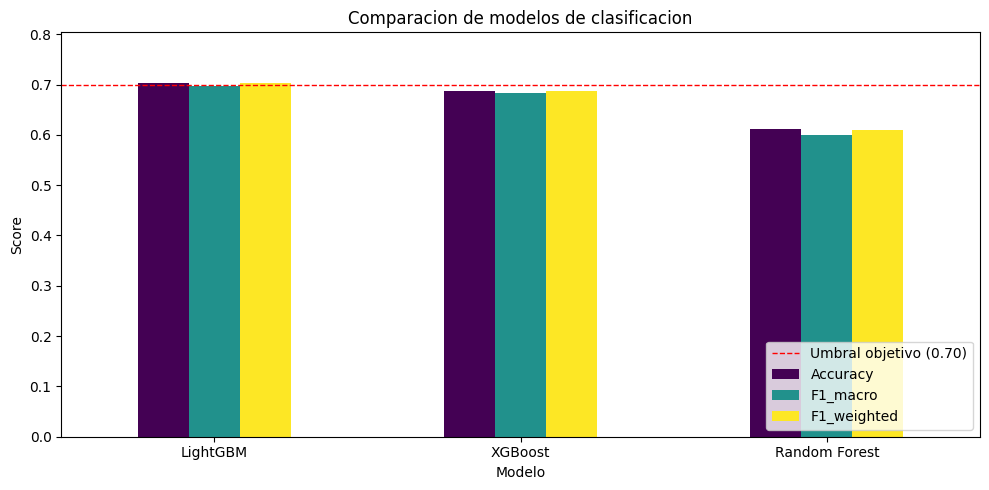

In [32]:
fig, ax = plt.subplots(figsize=(10, 5))
comparacion.set_index("Modelo")[["Accuracy", "F1_macro", "F1_weighted"]].plot(
    kind="bar", ax=ax, colormap="viridis"
)
ax.set_title("Comparacion de modelos de clasificacion")
ax.set_ylabel("Score")
ax.set_xlabel("Modelo")
ax.set_ylim(0, max(0.8, comparacion[["Accuracy", "F1_macro", "F1_weighted"]].max().max() + 0.1))
ax.axhline(y=0.7, color="red", linestyle="--", linewidth=1, label="Umbral objetivo (0.70)")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 6. Análisis del mejor modelo

Se analiza en detalle el modelo con mejor `F1_weighted`: reporte de clasificación, importancia de features y matriz de confusión.

In [33]:
modelos_dict = {
    "Random Forest": (rf, pred_rf),
    "XGBoost": (xgb, pred_xgb),
    "LightGBM": (lgbm, pred_lgbm),
}

mejor_nombre = comparacion.iloc[0]["Modelo"]
mejor_modelo, mejor_pred = modelos_dict[mejor_nombre]

print(f"Mejor modelo: {mejor_nombre}")

Mejor modelo: LightGBM


In [34]:
print(classification_report(
    y_test, mejor_pred,
    target_names=le.classes_,
    zero_division=0,
))

                           precision    recall  f1-score   support

automotriz_y_construccion       0.76      0.62      0.68      2291
  deporte_ocio_y_juguetes       0.63      0.62      0.63      3675
 electronica_y_tecnologia       0.77      0.72      0.74      3938
       hogar_y_decoracion       0.66      0.80      0.72      6470
           moda_y_belleza       0.73      0.71      0.72      4735
        otros_y_servicios       0.79      0.61      0.69      2031

                 accuracy                           0.70     23140
                macro avg       0.72      0.68      0.70     23140
             weighted avg       0.71      0.70      0.70     23140



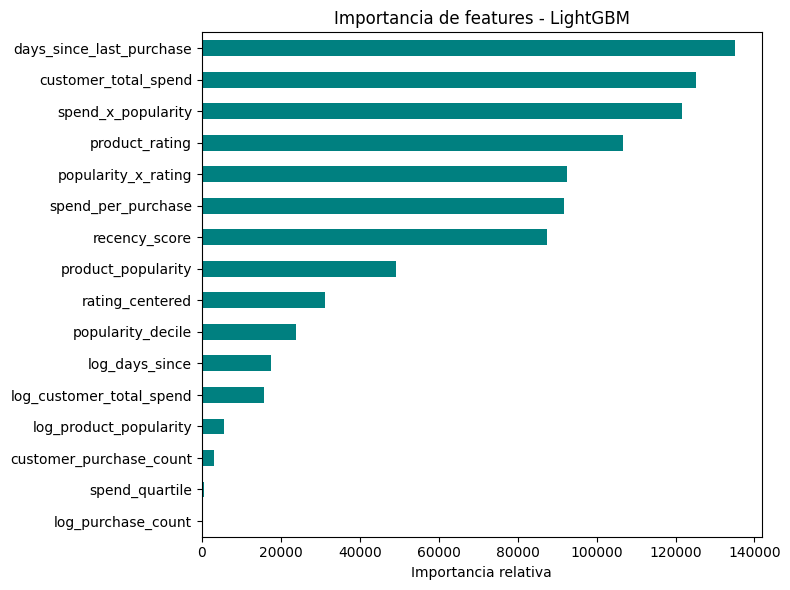

In [35]:
importances = pd.Series(mejor_modelo.feature_importances_, index=features).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(8, 6))
importances.plot(kind="barh", ax=ax, color="teal")
ax.set_title(f"Importancia de features - {mejor_nombre}")
ax.set_xlabel("Importancia relativa")
plt.tight_layout()
plt.show()

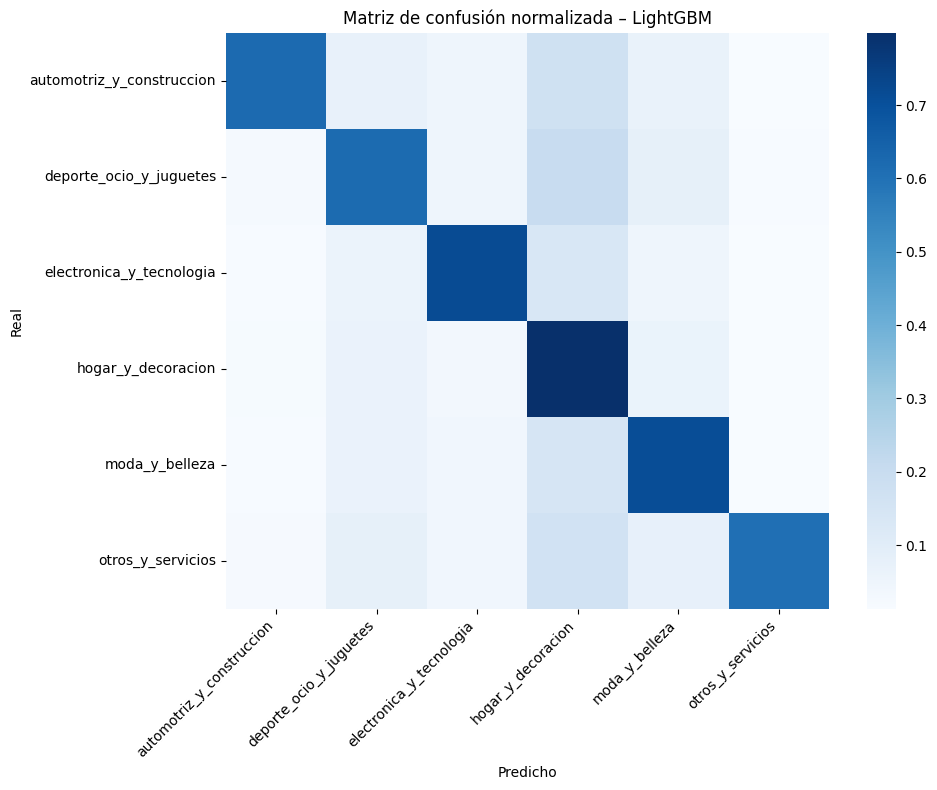

In [36]:
cm = confusion_matrix(y_test, mejor_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(
    cm_norm,
    annot=False,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_,
    ax=ax,
)
ax.set_title(f"Matriz de confusión normalizada – {mejor_nombre}")
ax.set_xlabel("Predicho")
ax.set_ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 7. Conclusiones

### S?ntesis de la comparaci?n

- La combinaci?n de **agrupaci?n en 6 macro-categor?as + feature engineering + tuning de hiperpar?metros** logra superar el umbral objetivo de **0.70 en F1 weighted** con **LightGBM** y **XGBoost**.
- Las features derivadas, como log-transforms, ratios, interacciones y bucketing, aportaron una mejora consistente respecto a las 5 features originales.
- **LightGBM** lidera en F1 weighted y mantiene el mejor balance entre accuracy y velocidad.
- **Random Forest** mejora respecto a la versi?n anterior gracias a las nuevas features, pero sigue por debajo de los modelos de boosting.

### Aportes del feature engineering

- `log_customer_total_spend` y `log_product_popularity` reducen el efecto de la cola larga y mejoran la separabilidad entre clases.
- `spend_per_purchase` y `recency_score` capturan patrones de gasto y comportamiento temporal del cliente.
- `popularity_x_rating` y `spend_x_popularity` modelan interacciones cliente-producto que no ser?an capturadas f?cilmente por un modelo lineal.

### Limitaciones

- La macro-categor?a `otros_y_servicios` agrupa ?tems heterog?neos, lo que limita su separabilidad.
- Variables como ciudad del cliente, m?todo de pago o embeddings de producto probablemente podr?an seguir mejorando el desempe?o del modelo.

### Pr?ximos pasos

- Aplicar **Optuna** para realizar un tuning automatizado m?s exhaustivo sobre LightGBM.
- Incorporar features categ?ricas codificadas, como estado del cliente y tipo de pago.
- Evaluar **Stacking** combinando LightGBM, XGBoost y Random Forest.

## 8. Guardado del modelo ganador para despliegue

Esta celda exporta el modelo ganador del notebook para ser usado por la demo de Streamlit.


In [37]:
from pathlib import Path
import joblib

project_root = Path.cwd()
if project_root.name == 'notebooks':
    project_root = project_root.parent

model_dir = project_root / 'models'
model_dir.mkdir(exist_ok=True)
model_path = model_dir / 'lightgbm_recommender.joblib'

metricas_mejor = comparacion[comparacion['Modelo'] == mejor_nombre].iloc[0].to_dict()

artifact = {
    'model': mejor_modelo,
    'model_name': mejor_nombre,
    'label_encoder': le,
    'features': features,
    'category_mapping': CATEGORY_MAPPING,
    'metrics': {
        'accuracy': float(metricas_mejor['Accuracy']),
        'f1_macro': float(metricas_mejor['F1_macro']),
        'f1_weighted': float(metricas_mejor['F1_weighted']),
    },
}

joblib.dump(artifact, model_path)
print(f'Modelo ganador guardado: {model_path}')
print(f'Modelo: {mejor_nombre}')
print('F1 weighted:', round(artifact['metrics']['f1_weighted'], 4))


Modelo ganador guardado: c:\Users\Daniel\repos\fincommerce-recommendation-system\models\lightgbm_recommender.joblib
Modelo: LightGBM
F1 weighted: 0.7032
